# 📊 Análise do Programa Pé de Meia

Este projeto tem como objetivo analisar a distribuição de recursos do programa Pé de Meia no Brasil, explorando padrões por estado, município e evolução temporal dos pagamentos.

A análise busca responder:

- Como os recursos estão distribuídos geograficamente?
- Quais estados concentram maior volume financeiro?
- Como os pagamentos evoluem ao longo do tempo?

Estrutura para o notebook

📌 Célula 1 – Importar bibliotecas

In [ ]:
!pip install seaborn

In [ ]:
pip install unidecode

In [1]:
# Importação da biblioteca para manipulação de dados em tabelas
import pandas as pd  

# Importação da biblioteca NumPy para operações matemáticas e arrays
import numpy as np  

# Importação da biblioteca Matplotlib para geração de gráficos
import matplotlib.pyplot as plt  

# Importação da biblioteca Seaborn para visualização estatística de dados
import seaborn as sns  

# Importação da biblioteca random para geração de números aleatórios
import random  

# Importação das classes datetime e timedelta para manipulação de datas e intervalos de tempo
from datetime import datetime, timedelta  

# Comando mágico do Jupyter Notebook que permite exibir gráficos diretamente no notebook
%matplotlib inline  
import os
import zipfile
import glob
import unidecode


In [2]:
# Instala o pacote watermark
!pip install -q -U watermark

In [3]:
%reload_ext watermark
%watermark -a "Luis Antonio" 

Author: Luis Antonio



In [4]:
%watermark --iversions

matplotlib: 3.10.8
numpy     : 2.2.6
pandas    : 2.3.3
seaborn   : 0.13.2
unidecode : 1.4.0



📌 Célula 2 – Extrair todos os CSVs dos zips

In [ ]:
# Caminho base onde estão os arquivos zip
caminho_base = r"C:\Users\User\Documents\CursoDSA\99_analise_dados_reais\202501_PeDeMeia"

# Pasta destino para extrair os CSVs
destino = os.path.join(caminho_base, "csv_extraidos")
os.makedirs(destino, exist_ok=True)

# Lista dos arquivos zip (de janeiro a novembro)
arquivos_zip = [
    "202501_PeDeMeia.zip",
    "202502_PeDeMeia.zip",
    "202503_PeDeMeia.zip",
    "202504_PeDeMeia.zip",
    "202505_PeDeMeia.zip",
    "202506_PeDeMeia.zip",
    "202507_PeDeMeia.zip",
    "202508_PeDeMeia.zip",
    "202509_PeDeMeia.zip",
    "202510_PeDeMeia.zip",
    "202511_PeDeMeia.zip"
]

# Extrair todos os CSVs para a pasta destino
for zip_name in arquivos_zip:
    zip_path = os.path.join(caminho_base, zip_name)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for nome in zip_ref.namelist():
            if nome.endswith(".csv"):
                zip_ref.extract(nome, destino)

print("Extração concluída. Os CSVs estão na pasta:", destino)


In [5]:
caminho_base = r"C:\Users\User\Documents\CursoDSA\99_analise_dados_reais\202501_PeDeMeia"
destino = os.path.join(caminho_base, "csv_extraidos")

os.makedirs(destino, exist_ok=True)

arquivos_zip = glob.glob(os.path.join(caminho_base, "*.zip"))

# Evita reextrair se já existir
if not os.listdir(destino):
    for zip_path in arquivos_zip:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(destino)

print("Extração concluída.")

Extração concluída.


📌 Célula 3 – Ler e concatenar os CSVs

In [6]:
# Lista todos os CSVs extraídos
arquivos_csv = glob.glob(os.path.join(destino, "*.csv"))

# Lê e concatena todos os CSVs
df_final = pd.concat(
    [pd.read_csv(arq, sep=";", encoding="latin1") for arq in arquivos_csv],
    ignore_index=True
)

print("Shape final:", df_final.shape)
df_final.head()


C:\Users\User\AppData\Local\Temp\ipykernel_16160\3444232612.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(arq, sep=";", encoding="latin1") for arq in arquivos_csv],
C:\Users\User\AppData\Local\Temp\ipykernel_16160\3444232612.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(arq, sep=";", encoding="latin1") for arq in arquivos_csv],
C:\Users\User\AppData\Local\Temp\ipykernel_16160\3444232612.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(arq, sep=";", encoding="latin1") for arq in arquivos_csv],
C:\Users\User\AppData\Local\Temp\ipykernel_16160\3444232612.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(arq, sep=";", encoding="latin1") for arq in arquivos_csv],
C:\Users\User\AppData\Local\Temp\ipykern

Shape final: (36154991, 18)


,MÊS FOLHA,MÊS REFERÊNCIA,UF,CÓDIGO MUNICÍPIO SIAFI,NOME MUNICÍPIO,NIS BENEFICIÁRIO,CPF BENEFICIÁRIO,NOME BENEFICIÁRIO,NIS RESPONSÁVEL,CPF RESPONSÁVEL,NOME RESPONSÁVEL,CÓDIGO TIPO INCENTIVO,TIPO INCENTIVO,PERÍODO INCENTIVO,CÓDIGO ETAPA ENSINO,ETAPA ENSINO,DATA DO PAGAMENTO,VALOR PARCELA
0,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,ANA FRANCISCA LOPES DE ALBUQUERQUE,2,Frequência,Outubro/Novembro 2024,27,3º ano - Ensino Médio Regular,28/01/2025,"200,00"
1,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,ANA FRANCISCA LOPES DE ALBUQUERQUE,2,Frequência,Julho/Agosto 2024,27,3º ano - Ensino Médio Regular,28/01/2025,"200,00"
2,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,ANA FRANCISCA LOPES DE ALBUQUERQUE,2,Frequência,Setembro 2024,27,3º ano - Ensino Médio Regular,28/01/2025,"200,00"
3,202501,202501,AC,643,ACRELANDIA,2.123272e+10,***.981.032-**,ANA CLARA BORGES PINTO,1.272483e+10,***.775.892-**,ADAMOR FERREIRA PINTO,2,Frequência,Maio 2024,27,3º ano - Ensino Médio Regular,03/02/2025,"200,00"
4,202501,202501,AC,643,ACRELANDIA,2.121326e+10,***.556.712-**,ANTONIO RICARDO SILVA DA COSTA,2.121328e+10,***.525.152-**,ELIANE DE JESUS DA SILVA,2,Frequência,Setembro 2024,45,EJA - Educação de Jovens e Adultos,31/01/2025,"225,00"


📌 Célula 4 – Criar colunas auxiliares (ano, mês)

In [8]:
# Converter coluna "MÊS FOLHA" para datetime
df_final['ano_mes'] = pd.to_datetime(df_final['MÊS FOLHA'], format='%Y%m')
df_final['ano'] = df_final['ano_mes'].dt.year
df_final['mes'] = df_final['ano_mes'].dt.month

df_final[['MÊS FOLHA','ano','mes']].head()


,MÊS FOLHA,ano,mes
0,202501,2025,1
1,202501,2025,1
2,202501,2025,1
3,202501,2025,1
4,202501,2025,1


In [10]:
df_final.head()

,MÊS FOLHA,MÊS REFERÊNCIA,UF,CÓDIGO MUNICÍPIO SIAFI,NOME MUNICÍPIO,NIS BENEFICIÁRIO,CPF BENEFICIÁRIO,NOME BENEFICIÁRIO,NIS RESPONSÁVEL,CPF RESPONSÁVEL,...,CÓDIGO TIPO INCENTIVO,TIPO INCENTIVO,PERÍODO INCENTIVO,CÓDIGO ETAPA ENSINO,ETAPA ENSINO,DATA DO PAGAMENTO,VALOR PARCELA,ano_mes,ano,mes
0,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,...,2,Frequência,Outubro/Novembro 2024,27,3º ano - Ensino Médio Regular,28/01/2025,"200,00",2025-01-01,2025,1
1,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,...,2,Frequência,Julho/Agosto 2024,27,3º ano - Ensino Médio Regular,28/01/2025,"200,00",2025-01-01,2025,1
2,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,...,2,Frequência,Setembro 2024,27,3º ano - Ensino Médio Regular,28/01/2025,"200,00",2025-01-01,2025,1
3,202501,202501,AC,643,ACRELANDIA,2.123272e+10,***.981.032-**,ANA CLARA BORGES PINTO,1.272483e+10,***.775.892-**,...,2,Frequência,Maio 2024,27,3º ano - Ensino Médio Regular,03/02/2025,"200,00",2025-01-01,2025,1
4,202501,202501,AC,643,ACRELANDIA,2.121326e+10,***.556.712-**,ANTONIO RICARDO SILVA DA COSTA,2.121328e+10,***.525.152-**,...,2,Frequência,Setembro 2024,45,EJA - Educação de Jovens e Adultos,31/01/2025,"225,00",2025-01-01,2025,1


📌 Célula 5 – Exportar consolidado

In [11]:
# Salvar em CSV final
saida_csv = os.path.join(caminho_base, "pe_de_meia_final.csv")
df_final.to_csv(saida_csv, index=False, encoding="utf-8")

print("Arquivo final salvo em:", saida_csv)


Arquivo final salvo em: C:\Users\User\Documents\CursoDSA\99_analise_dados_reais\202501_PeDeMeia\pe_de_meia_final.csv


📌 6. Limpeza e Padronização



**Normalização das Colunas**


In [12]:
# Normalizar nomes de colunas
df_final.columns = (
    df_final.columns
    .str.normalize('NFKD')  # remove acentos
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
    .str.replace(' ', '_')  # troca espaço por underscore
    .str.upper()            # deixa tudo maiúsculo
)

print(df_final.columns)


Index(['MES_FOLHA', 'MES_REFERENCIA', 'UF', 'CODIGO_MUNICIPIO_SIAFI',
       'NOME_MUNICIPIO', 'NIS_BENEFICIARIO', 'CPF_BENEFICIARIO',
       'NOME_BENEFICIARIO', 'NIS_RESPONSAVEL', 'CPF_RESPONSAVEL',
       'NOME_RESPONSAVEL', 'CODIGO_TIPO_INCENTIVO', 'TIPO_INCENTIVO',
       'PERIODO_INCENTIVO', 'CODIGO_ETAPA_ENSINO', 'ETAPA_ENSINO',
       'DATA_DO_PAGAMENTO', 'VALOR_PARCELA', 'ANO_MES', 'ANO', 'MES'],
      dtype='object')


🔹 Converter valores

In [13]:
df_final['VALOR_PARCELA'] = (
    df_final['VALOR_PARCELA']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [14]:
df_final.head()

,MES_FOLHA,MES_REFERENCIA,UF,CODIGO_MUNICIPIO_SIAFI,NOME_MUNICIPIO,NIS_BENEFICIARIO,CPF_BENEFICIARIO,NOME_BENEFICIARIO,NIS_RESPONSAVEL,CPF_RESPONSAVEL,...,CODIGO_TIPO_INCENTIVO,TIPO_INCENTIVO,PERIODO_INCENTIVO,CODIGO_ETAPA_ENSINO,ETAPA_ENSINO,DATA_DO_PAGAMENTO,VALOR_PARCELA,ANO_MES,ANO,MES
0,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,...,2,Frequência,Outubro/Novembro 2024,27,3º ano - Ensino Médio Regular,28/01/2025,200.0,2025-01-01,2025,1
1,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,...,2,Frequência,Julho/Agosto 2024,27,3º ano - Ensino Médio Regular,28/01/2025,200.0,2025-01-01,2025,1
2,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,...,2,Frequência,Setembro 2024,27,3º ano - Ensino Médio Regular,28/01/2025,200.0,2025-01-01,2025,1
3,202501,202501,AC,643,ACRELANDIA,2.123272e+10,***.981.032-**,ANA CLARA BORGES PINTO,1.272483e+10,***.775.892-**,...,2,Frequência,Maio 2024,27,3º ano - Ensino Médio Regular,03/02/2025,200.0,2025-01-01,2025,1
4,202501,202501,AC,643,ACRELANDIA,2.121326e+10,***.556.712-**,ANTONIO RICARDO SILVA DA COSTA,2.121328e+10,***.525.152-**,...,2,Frequência,Setembro 2024,45,EJA - Educação de Jovens e Adultos,31/01/2025,225.0,2025-01-01,2025,1


🔹 Criar colunas de data

In [15]:
df_final['ANO_MES'] = pd.to_datetime(df_final['MES_FOLHA'], format='%Y%m')
df_final['ANO'] = df_final['ANO_MES'].dt.year
df_final['MES'] = df_final['ANO_MES'].dt.month

In [16]:
df_final.head()

,MES_FOLHA,MES_REFERENCIA,UF,CODIGO_MUNICIPIO_SIAFI,NOME_MUNICIPIO,NIS_BENEFICIARIO,CPF_BENEFICIARIO,NOME_BENEFICIARIO,NIS_RESPONSAVEL,CPF_RESPONSAVEL,...,CODIGO_TIPO_INCENTIVO,TIPO_INCENTIVO,PERIODO_INCENTIVO,CODIGO_ETAPA_ENSINO,ETAPA_ENSINO,DATA_DO_PAGAMENTO,VALOR_PARCELA,ANO_MES,ANO,MES
0,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,...,2,Frequência,Outubro/Novembro 2024,27,3º ano - Ensino Médio Regular,28/01/2025,200.0,2025-01-01,2025,1
1,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,...,2,Frequência,Julho/Agosto 2024,27,3º ano - Ensino Médio Regular,28/01/2025,200.0,2025-01-01,2025,1
2,202501,202501,AC,643,ACRELANDIA,2.363854e+10,***.502.002-**,ADELINO ALBUQUERQUE DA SILVA,1.616560e+10,***.226.672-**,...,2,Frequência,Setembro 2024,27,3º ano - Ensino Médio Regular,28/01/2025,200.0,2025-01-01,2025,1
3,202501,202501,AC,643,ACRELANDIA,2.123272e+10,***.981.032-**,ANA CLARA BORGES PINTO,1.272483e+10,***.775.892-**,...,2,Frequência,Maio 2024,27,3º ano - Ensino Médio Regular,03/02/2025,200.0,2025-01-01,2025,1
4,202501,202501,AC,643,ACRELANDIA,2.121326e+10,***.556.712-**,ANTONIO RICARDO SILVA DA COSTA,2.121328e+10,***.525.152-**,...,2,Frequência,Setembro 2024,45,EJA - Educação de Jovens e Adultos,31/01/2025,225.0,2025-01-01,2025,1


📌 7. Análises


📊 Top Estados

In [19]:
top_estados = (
    df_final.groupby("UF")["VALOR_PARCELA"]
    .sum()
    .sort_values(ascending=False)
    .head()
)

In [20]:
top_estados.head()

UF
SP    1.198506e+09
BA    1.040464e+09
MG    8.020322e+08
CE    7.314846e+08
PA    7.286508e+08
Name: VALOR_PARCELA, dtype: float64

🏙️ Top Municípios

In [21]:
top_municipios = (
    df_final.groupby("NOME_MUNICIPIO")["VALOR_PARCELA"]
    .sum()
    .sort_values(ascending=False)
    .head()
)

In [22]:
top_municipios.head()

NOME_MUNICIPIO
SAO PAULO         313715750.0
RIO DE JANEIRO    222052425.0
MANAUS            166602000.0
FORTALEZA         154249600.0
SALVADOR          128519300.0
Name: VALOR_PARCELA, dtype: float64

📌 Insight:
Alguns municípios concentram volumes expressivos de pagamentos, o que pode indicar polos populacionais ou áreas prioritárias do programa.

📈 Evolução Mensal

In [23]:
evolucao_mensal = (
    df_final.groupby("ANO_MES")["VALOR_PARCELA"]
    .sum()
)

In [24]:
evolucao_mensal.head()

ANO_MES
2025-01-01    1.115128e+08
2025-02-01    3.132518e+09
2025-03-01    9.448577e+08
2025-04-01    6.964255e+08
2025-05-01    7.884388e+08
Name: VALOR_PARCELA, dtype: float64

📌 8. Visualizações

📊 Estados

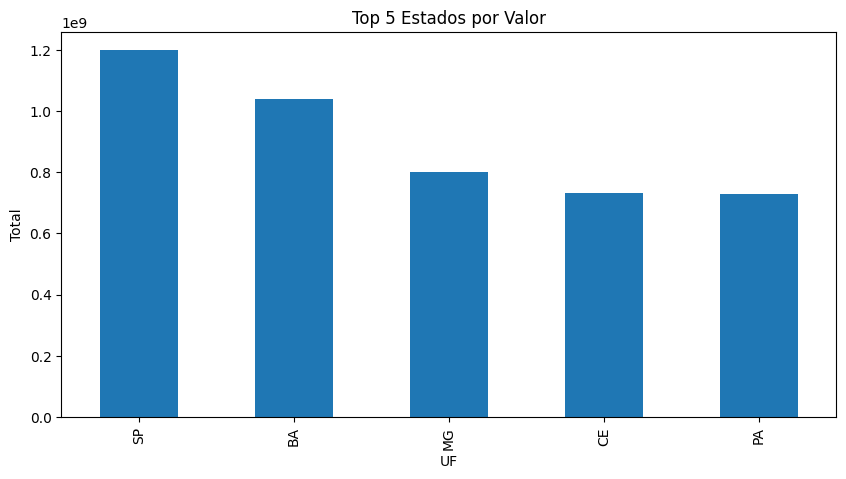

In [31]:
plt.figure(figsize=(10,5))
top_estados.plot(kind='bar')
plt.title("Top 5 Estados por Valor")
plt.ylabel("Total")
plt.show()

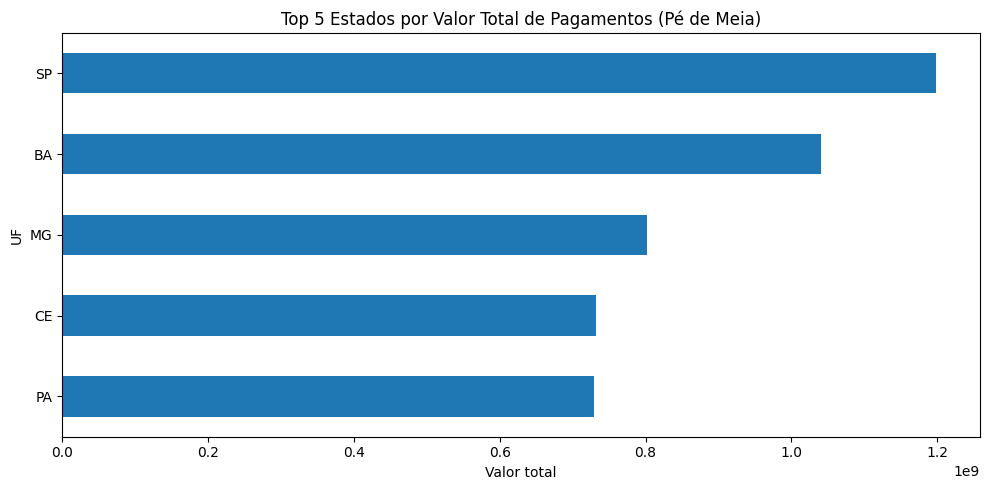

In [32]:
plt.figure(figsize=(10,5))
top_estados.sort_values().plot(kind='barh')
plt.title("Top 5 Estados por Valor Total de Pagamentos (Pé de Meia)")
plt.xlabel("Valor total")
plt.tight_layout()
plt.show()

📌 Insight:
Os dados indicam forte concentração dos pagamentos em determinados estados, sugerindo desigualdade na distribuição dos recursos ou maior adesão regional ao programa.

📈 Evolução no tempo

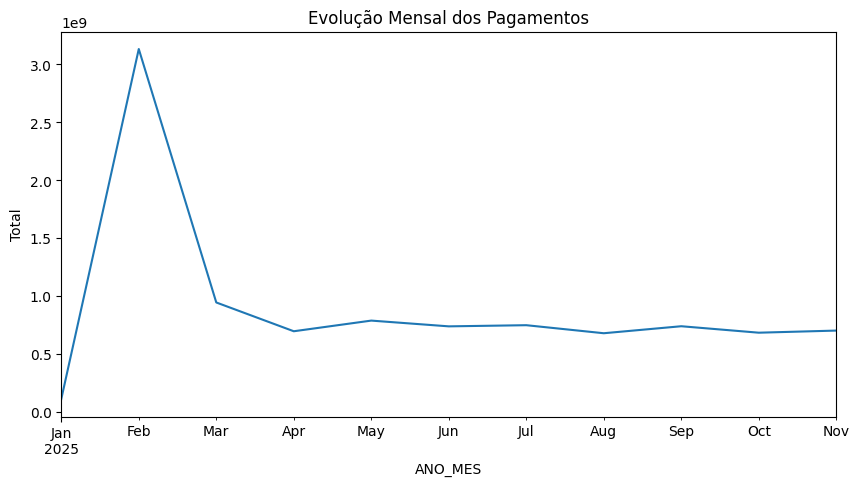

In [26]:
plt.figure(figsize=(10,5))
evolucao_mensal.plot()
plt.title("Evolução Mensal dos Pagamentos")
plt.ylabel("Total")
plt.show()

📌 Insight:
A série temporal dos pagamentos permite identificar padrões de crescimento, estabilidade ou sazonalidade na execução do programa.

📊 NOVA SEÇÃO: “Análise complementar de municípios”
🔹 Top 10 municípios

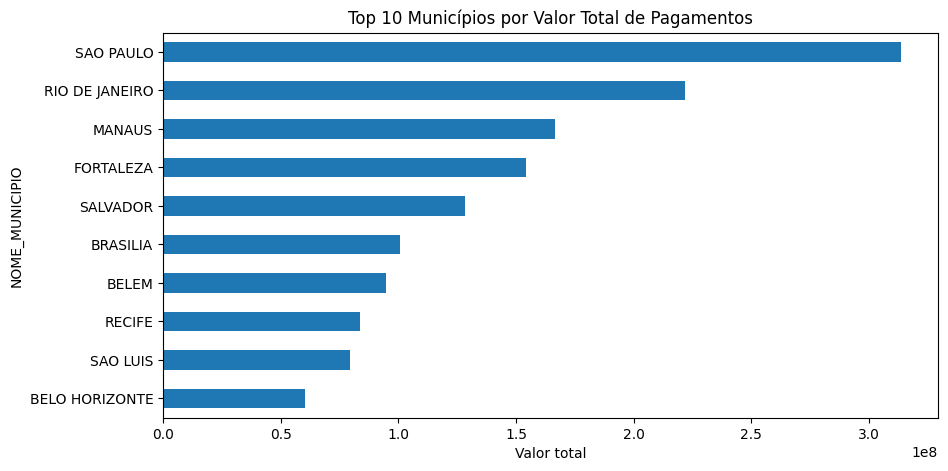

In [28]:
top_municipios = (
    df_final.groupby("NOME_MUNICIPIO")["VALOR_PARCELA"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_municipios.sort_values().plot(kind='barh')
plt.title("Top 10 Municípios por Valor Total de Pagamentos")
plt.xlabel("Valor total")
plt.show()

🔹 Distribuição (visão mais ampla)

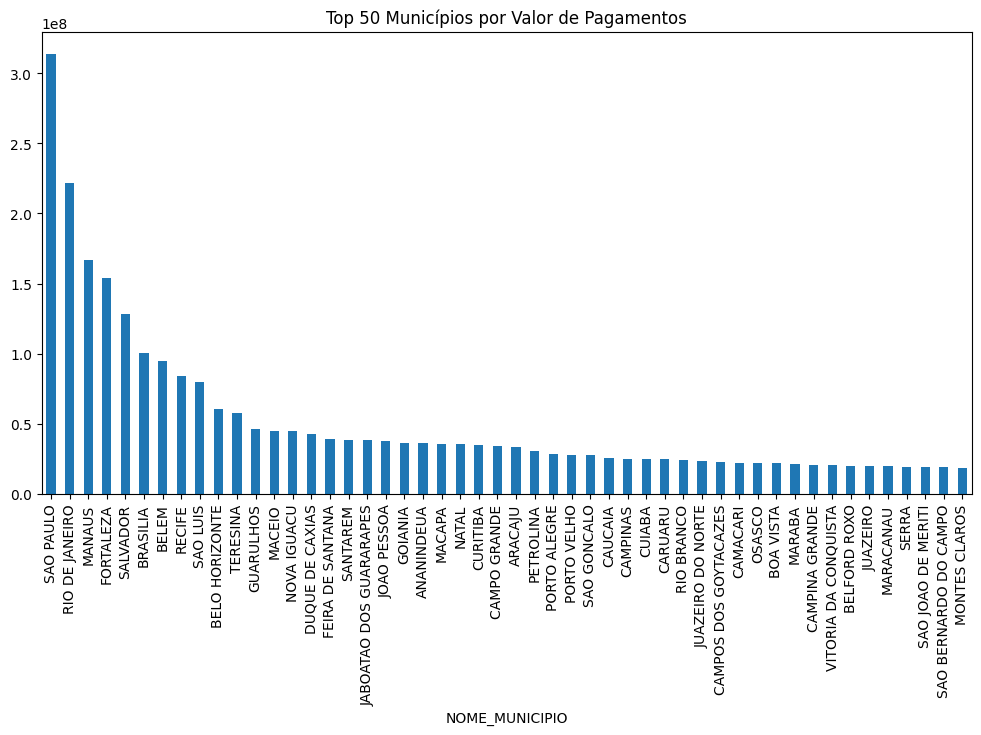

In [29]:
municipios_top50 = (
    df_final.groupby("NOME_MUNICIPIO")["VALOR_PARCELA"]
    .sum()
    .sort_values(ascending=False)
    .head(50)
)

plt.figure(figsize=(12,6))
municipios_top50.plot(kind='bar')
plt.title("Top 50 Municípios por Valor de Pagamentos")
plt.xticks(rotation=90)
plt.show()

## 📌 Leitura dos dados por município

A análise dos municípios revela forte concentração dos pagamentos em um conjunto reduzido de localidades.

Esse comportamento indica que a execução do programa não ocorre de forma homogênea, refletindo diferenças regionais na distribuição dos recursos.

📌 9. Exportação

In [27]:
saida = os.path.join(caminho_base, "pe_de_meia_tratado.csv")
df_final.to_csv(saida, index=False, encoding="utf-8")

print("Arquivo salvo:", saida)

Arquivo salvo: C:\Users\User\Documents\CursoDSA\99_analise_dados_reais\202501_PeDeMeia\pe_de_meia_tratado.csv


## 📌 Conclusão

A análise evidencia padrões relevantes na distribuição de recursos públicos, permitindo interpretações sobre concentração geográfica e dinâmica temporal dos pagamentos.

Este tipo de análise pode apoiar decisões de políticas públicas e monitoramento de programas sociais.




## 📌 Resumo executivo

Os dados indicam forte concentração dos pagamentos em determinados estados e municípios, com padrão de distribuição desigual ao longo do território nacional.

A evolução temporal sugere comportamento consistente dos pagamentos ao longo dos meses, com variações associadas à execução do programa.
